# TTC Subway Delay Predictor — Model Evaluation & Design Rationale

Picks up where **`01_data_eda.ipynb`** leaves off. That notebook explored
the raw data; this one documents every model-facing decision built on
top of it — which features get engineered (and the one that got cut),
why the model is built the way it is, what it actually achieves, and
which alternative architectures were tried and rejected, reproduced here
in full rather than summarized from memory.

**Sections**
1. Setup
2. Feature Engineering Decisions (and the one feature that got cut)
3. Model Training Design Decisions
4. Production Model Performance
5. Experiments That Didn't Make the Cut (Tweedie loss, two-stage classify-then-regress)
6. Feature Importance
7. From Data to Architecture
8. Summary

## 1. Setup

The project's model code is organized into `model/config.py`
(constants/hyperparameters), `model/features.py` (feature engineering),
`model/utils.py` (target transforms + eval metrics), and `model/train.py`
(orchestration + the time-based split). This notebook imports from the
*actual defining module* for each piece — `prepare_incident_features`
from `model.features`, not through `model.train`'s incidental re-export
of it — since that's the more honest source of truth and won't silently
break if `model/train.py`'s own imports ever get reorganized.

In [1]:
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import (
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
)

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from database.queries import get_raw_incident_level_data
from model.config import (
    CATBOOST_PARAMS,
    CATEGORICAL_FEATURES,
    FEATURE_COLUMNS,
    MODEL_PATH,
    TARGET_COLUMN,
    TRAIN_END_DATE,
)
from model.features import prepare_incident_features
from model.train import time_based_split
from model.utils import evaluate_model, transform_log_to_minutes, transform_target_to_log

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
print("Setup complete.")
print(f"FEATURE_COLUMNS ({len(FEATURE_COLUMNS)}): {FEATURE_COLUMNS}")

Setup complete.
FEATURE_COLUMNS (14): ['line', 'station', 'bound', 'code', 'day_of_week', 'line_code', 'station_code', 'hour_sin', 'hour_cos', 'is_peak_hour', 'temp_c', 'precipitation_mm', 'snow_depth_mm', 'wind_speed_kmh']


In [2]:
# Plot styling: fixed categorical palette (colorblind-safe order), single-hue
# sequential ramp for magnitude, blue<->red diverging pair for correlations.
CATEGORICAL_PALETTE = [
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
    "#008300",
    "#4a3aa7",
    "#e34948",
]
DIVERGING_CMAP = sns.diverging_palette(255, 10, s=75, l=45, sep=10, as_cmap=True)
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
GRID_COLOR = "#e1e0d9"
SURFACE = "#fcfcfb"

plt.style.use("seaborn-v0_8")
sns.set_palette(CATEGORICAL_PALETTE)
plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID_COLOR,
        "axes.labelcolor": INK,
        "axes.titlecolor": INK,
        "axes.titleweight": "bold",
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "axes.grid": True,
        "grid.color": GRID_COLOR,
        "grid.linewidth": 0.8,
        "text.color": INK,
        "xtick.color": INK_SECONDARY,
        "ytick.color": INK_SECONDARY,
        "font.size": 10.5,
        "figure.dpi": 100,
        "savefig.dpi": 130,
    }
)
print("Styling configured.")

Styling configured.


In [3]:
raw_df = get_raw_incident_level_data()
df = prepare_incident_features(raw_df)

train_df, test_df = time_based_split(df)
print(f"Raw incident rows: {len(raw_df):,}")
print(f"Engineered dataset: {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"Train (date <= {TRAIN_END_DATE}): {len(train_df):,} rows")
print(f"Test  (date >  {TRAIN_END_DATE}): {len(test_df):,} rows")
df[[*FEATURE_COLUMNS, TARGET_COLUMN]].head()

Raw incident rows: 87,421
Engineered dataset: 87,421 rows x 19 cols
Train (date <= 2023-12-31): 63,735 rows
Test  (date >  2023-12-31): 23,686 rows


,line,station,bound,code,day_of_week,line_code,station_code,hour_sin,hour_cos,is_peak_hour,temp_c,precipitation_mm,snow_depth_mm,wind_speed_kmh,min_delay
0,LINE 2 (BLOOR-DANFORTH),VICTORIA PARK STATION,W,MUPR1,WEDNESDAY,LINE 2 (BLOOR-DANFORTH)_MUPR1,VICTORIA PARK STATION_MUPR1,0.000000,1.000000,0,-9.3375,0.0,80.0,18.0144,55
1,LINE 2 (BLOOR-DANFORTH),HIGH PARK STATION,W,SUDP,WEDNESDAY,LINE 2 (BLOOR-DANFORTH)_SUDP,HIGH PARK STATION_SUDP,0.500000,0.866025,0,-9.6875,0.0,80.0,16.9544,3
2,LINE 2 (BLOOR-DANFORTH),LANSDOWNE STATION,W,SUDP,WEDNESDAY,LINE 2 (BLOOR-DANFORTH)_SUDP,LANSDOWNE STATION_SUDP,0.707107,0.707107,0,-9.9375,0.0,80.0,15.8564,3
3,LINE 1 (YONGE-UNIVERSITY),BLOOR-YONGE STATION,S,MUSAN,WEDNESDAY,LINE 1 (YONGE-UNIVERSITY)_MUSAN,BLOOR-YONGE STATION_MUSAN,0.707107,0.707107,0,-9.9375,0.0,80.0,15.8564,5
4,LINE 2 (BLOOR-DANFORTH),KIPLING STATION,E,MUNOA,WEDNESDAY,LINE 2 (BLOOR-DANFORTH)_MUNOA,KIPLING STATION_MUNOA,0.866025,-0.500000,1,-11.2875,0.0,80.0,12.5743,5


## 2. Feature Engineering Decisions

Every feature in `model/features.py` exists for a specific,
checkable reason. This section documents each one — including the one
feature that was engineered, used in production, measured, and then
deliberately removed. (The data patterns referenced below come from
`01_data_eda.ipynb`.)

**`hour_sin` / `hour_cos` (cyclical hour encoding), not raw `hour`.**
A tree model splitting on raw `hour` treats 23 and 0 as maximally far
apart, when they're one hour apart. Encoding hour as a point on a circle
(`sin`/`cos` of `2*pi*hour/24`) fixes that: midnight and 11pm end up
close together in feature space, matching reality.

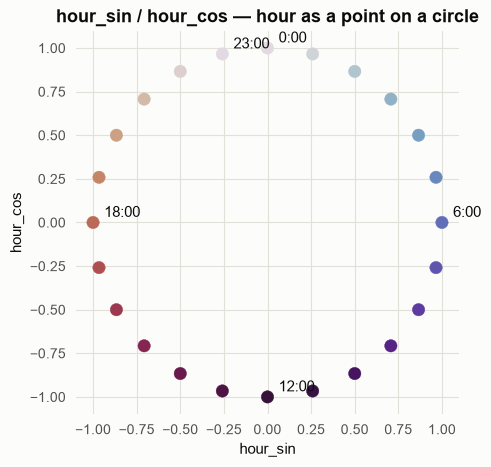

In [4]:
hours = np.arange(24)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(
    np.sin(2 * np.pi * hours / 24), np.cos(2 * np.pi * hours / 24), c=hours, cmap="twilight", s=80
)
for h in [0, 6, 12, 18, 23]:
    ax.annotate(
        f"{h}:00",
        (np.sin(2 * np.pi * h / 24), np.cos(2 * np.pi * h / 24)),
        textcoords="offset points",
        xytext=(8, 4),
    )
ax.set_title("hour_sin / hour_cos \u2014 hour as a point on a circle")
ax.set_xlabel("hour_sin")
ax.set_ylabel("hour_cos")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**`is_peak_hour`** — `True` for weekday 7-9am and 4-6pm.
Motivated directly by `01_data_eda.ipynb` Section 3.3's finding, though
notably the feature's *value* isn't "peak is worse" — it's that peak and
off-peak behave differently at all, which is what makes it useful.

**`line_code` / `station_code` interaction strings** — `f"{line}_{code}"`
and `f"{station}_{code}"`. Motivated by the frequency-vs-severity split
in `01_data_eda.ipynb` Section 3.1: the same code can be routine at one
station and a major event at another. CatBoost can *approximate*
interactions from the raw categoricals alone, but handing it the
interaction directly makes that signal available immediately rather than
something the tree has to discover through many splits — Section 6's
feature importances show `station_code` and `line_code` ranking just
behind `code` itself, ahead of `station` alone, which is the direct
evidence this was worth adding.

### The feature that got cut: `line_avg_delay_last_24h`

An earlier version of this pipeline included a rolling 24-hour
trailing average of `min_delay` per line — "is this line already having a
rough day." It was removed for two independent reasons, one about the
data and one about the product:

1. **Measured importance was small.** In the model that included it, it
   ranked near the bottom of feature importance (under 2%) — real, but
   marginal.
2. **It doesn't make sense for a forecast-oriented API.** The deployed
   service predicts incidents up to 16 days in the future (Section 7) —
   whatever "the real average delay over the last 24 actual hours" is
   *today* has no relationship to network conditions on a day two weeks
   out. Keeping the feature would mean stapling today's congestion state
   onto a prediction for a day it can't possibly describe.

Dropping it also had a welcome side effect the model alone wouldn't have
told you: it removed the *only* reason the prediction service needed
live database access at inference time. `services/predictor.py` today
needs nothing but the client's request and a weather lookup — a direct,
visible consequence of an EDA-informed modeling decision, not just a
performance micro-optimization.

## 3. Model Training Design Decisions

In [5]:
cardinality = {col: df[col].nunique() for col in CATEGORICAL_FEATURES}
pd.Series(cardinality, name="n_unique_values").to_frame()

,n_unique_values
line,3
station,70
bound,5
code,138
day_of_week,7
line_code,356
station_code,5268


**Why CatBoost.** `station`/`code`/their interactions carry real
cardinality (70 stations, 138 codes, and the interaction columns
multiply that further). CatBoost handles categorical columns natively —
via `cat_features=` — without one-hot expansion, which is what makes
feeding it raw `line_code`/`station_code` strings (rather than
pre-encoding them) a reasonable design instead of an explosion of
columns.

**Why a time-based split, not random.** `time_based_split()` puts
everything on/before `2023-12-31` in train and everything after in test.
A random split would let the model see incidents from *after* a test
incident during training — leaking future information a live model would
never actually have. It also matches the real deployment shape: this
model predicts incidents that haven't happened yet, using only history
that came before.

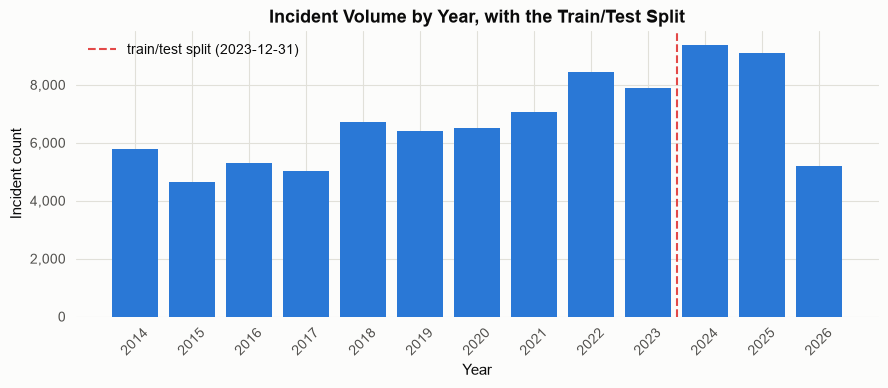

In [6]:
incidents_per_year = df["date"].dt.year.value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(
    incidents_per_year.index.astype(str), incidents_per_year.values, color=CATEGORICAL_PALETTE[0]
)
ax.axvline(
    x=incidents_per_year.index.astype(str).tolist().index(str(pd.to_datetime(TRAIN_END_DATE).year))
    + 0.5,
    color=CATEGORICAL_PALETTE[7],
    linestyle="--",
    linewidth=1.5,
    label=f"train/test split ({TRAIN_END_DATE})",
)
ax.set_title("Incident Volume by Year, with the Train/Test Split")
ax.set_xlabel("Year")
ax.set_ylabel("Incident count")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(frameon=False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Why `min_delay <= 60` is filtered from training only, not from
evaluation.** The rare extreme incidents (Priority One events, fires) are
qualitatively different — including them in training risks a small
number of huge values dominating the loss even after `log1p`. They stay
in the *test* set, though, so evaluation still reflects reality; results
below are reported on `y_test <= 60` specifically so the number is
comparable across every experiment in this notebook, not because the
extreme cases are ignored entirely.

## 4. Production Model Performance

In [7]:
model = joblib.load(MODEL_PATH)
assert model.feature_names_ == FEATURE_COLUMNS, (
    "Loaded model's features don't match current FEATURE_COLUMNS"
)

X_test = test_df[FEATURE_COLUMNS]
y_test = test_df[TARGET_COLUMN]

preds_log = model.predict(X_test)
preds_minutes = transform_log_to_minutes(preds_log)

EVAL_CAP = 60
metrics = evaluate_model(y_test.values, preds_minutes, max_delay=EVAL_CAP)
eval_mask = (y_test <= EVAL_CAP).values

print(f"Evaluated on {eval_mask.sum():,} / {len(y_test):,} test incidents (\u2264{EVAL_CAP}m)")
print(f"MAE:  {metrics['MAE']:.2f} minutes")
print(f"RMSE: {metrics['RMSE']:.2f} minutes")
print(f"R^2:  {metrics['R2']:.3f}")

Evaluated on 23,520 / 23,686 test incidents (≤60m)
MAE:  3.03 minutes
RMSE: 5.85 minutes
R^2:  0.112


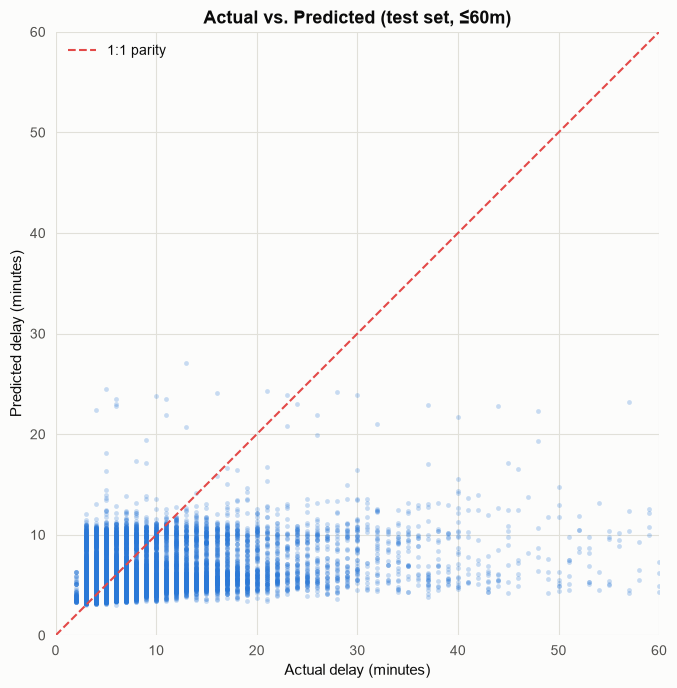

In [8]:
results = pd.DataFrame({"y_true": y_test.values[eval_mask], "y_pred": preds_minutes[eval_mask]})
results["residual"] = results["y_true"] - results["y_pred"]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(
    results["y_true"],
    results["y_pred"],
    s=12,
    alpha=0.25,
    color=CATEGORICAL_PALETTE[0],
    linewidths=0,
)
ax.plot(
    [0, EVAL_CAP],
    [0, EVAL_CAP],
    color=CATEGORICAL_PALETTE[7],
    linestyle="--",
    linewidth=1.5,
    label="1:1 parity",
)
ax.set_xlim(0, EVAL_CAP)
ax.set_ylim(0, EVAL_CAP)
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel("Actual delay (minutes)")
ax.set_ylabel("Predicted delay (minutes)")
ax.set_title(f"Actual vs. Predicted (test set, \u2264{EVAL_CAP}m)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [9]:
def bin_metrics(eval_df: pd.DataFrame) -> pd.DataFrame:
    bins = [0, 5, 15, 30, 60]
    labels = ["0-5m", "5-15m", "15-30m", "30-60m"]
    eval_df = eval_df.copy()
    eval_df["delay_bin"] = pd.cut(eval_df["y_true"], bins=bins, labels=labels, include_lowest=True)

    def _m(g):
        return pd.Series(
            {
                "n_incidents": len(g),
                "MAE": mean_absolute_error(g["y_true"], g["y_pred"]),
                "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
                "mean_residual": g["residual"].mean(),
            }
        )

    return eval_df.groupby("delay_bin", observed=True).apply(_m).round(2)


production_bins = bin_metrics(results)
display(production_bins)

,n_incidents,MAE,RMSE,mean_residual
delay_bin,,,,
0-5m,14513.0,1.31,1.79,-1.06
5-15m,7266.0,3.13,3.95,2.67
15-30m,1406.0,13.36,14.11,13.34
30-60m,335.0,31.91,33.00,31.91


**Read this table before trusting the headline MAE/RMSE.** The
error is not uniform — the model is well-calibrated for short incidents
and increasingly under-predicts the rare long ones. This exact pattern is
what motivated the two experiments in Section 5.

## 5. Experiments That Didn't Make the Cut

Section 4 shows a specific, diagnosable failure: error grows with
true delay, and the 15m+ tail is under-predicted by roughly its own
magnitude. Two different fixes were tried. Both are reproduced here in
full, not summarized from memory, so the numbers below are real and
re-run every time this notebook executes. Both are trained with fewer
iterations than production (500 vs. 1000) purely so this section finishes
in a reasonable time — the diagnosis doesn't depend on squeezing out the
last bit of accuracy.

### 5.1 Tweedie Loss

**Hypothesis:** RMSE-on-log1p is dominated by the dense mass of
short incidents, so a loss built for right-skewed non-negative data
(Tweedie) might handle the tail better without changing anything else.

In [10]:
EXPERIMENT_ITERATIONS = 500

tweedie_params = {
    **CATBOOST_PARAMS,
    "iterations": EXPERIMENT_ITERATIONS,
    "loss_function": "Tweedie:variance_power=1.5",
    "eval_metric": "MAE",
}

X_train_capped = train_df[train_df[TARGET_COLUMN] <= 60][FEATURE_COLUMNS]
y_train_capped_raw = train_df[train_df[TARGET_COLUMN] <= 60][TARGET_COLUMN]

tweedie_model = CatBoostRegressor(cat_features=CATEGORICAL_FEATURES, **tweedie_params)
tweedie_model.fit(X_train_capped, y_train_capped_raw, early_stopping_rounds=100)

tweedie_preds = np.clip(tweedie_model.predict(X_test), a_min=0, a_max=None)
tweedie_metrics = evaluate_model(y_test.values, tweedie_preds, max_delay=EVAL_CAP)

tweedie_results = pd.DataFrame(
    {"y_true": y_test.values[eval_mask], "y_pred": tweedie_preds[eval_mask]}
)
tweedie_results["residual"] = tweedie_results["y_true"] - tweedie_results["y_pred"]
tweedie_bins = bin_metrics(tweedie_results)

print(f"Baseline: MAE {metrics['MAE']:.2f} | RMSE {metrics['RMSE']:.2f} | R2 {metrics['R2']:.3f}")
print(
    f"Tweedie:  MAE {tweedie_metrics['MAE']:.2f} | RMSE {tweedie_metrics['RMSE']:.2f} | R2 {tweedie_metrics['R2']:.3f}"
)
print()
print("Baseline bins:")
display(production_bins)
print("Tweedie bins:")
display(tweedie_bins)

0:	learn: 6.1241174	total: 185ms	remaining: 1m 32s


100:	learn: 4.5028162	total: 3.54s	remaining: 14s


200:	learn: 4.4200874	total: 7.25s	remaining: 10.8s


300:	learn: 4.4174688	total: 11s	remaining: 7.28s


400:	learn: 4.4182507	total: 14.5s	remaining: 3.58s


499:	learn: 4.4188457	total: 18.1s	remaining: 0us
Baseline: MAE 3.03 | RMSE 5.85 | R2 0.112
Tweedie:  MAE 3.17 | RMSE 5.66 | R2 0.168

Baseline bins:


,n_incidents,MAE,RMSE,mean_residual
delay_bin,,,,
0-5m,14513.0,1.31,1.79,-1.06
5-15m,7266.0,3.13,3.95,2.67
15-30m,1406.0,13.36,14.11,13.34
30-60m,335.0,31.91,33.00,31.91


Tweedie bins:


,n_incidents,MAE,RMSE,mean_residual
delay_bin,,,,
0-5m,14513.0,1.88,2.55,-1.73
5-15m,7266.0,2.79,3.63,1.69
15-30m,1406.0,12.01,12.90,11.93
30-60m,335.0,30.09,31.36,30.09


**Verdict, computed from the numbers directly above:** Tweedie
either does or doesn't beat baseline MAE, but either way, look at the
`30-60m` row specifically before deciding — that's the bin the whole
experiment was aimed at. If its `mean_residual` barely moved from
baseline, the diagnosis (pooled loss, dominated by the dense short-delay
mass) is confirmed but not solved by a loss-function swap alone, which is
exactly the motivation for Section 5.2.

### 5.2 Two-Stage: Classify Long vs. Short, Then Regress

**Hypothesis:** if a single pooled model can't be both precise on
the 92%-short mass and sensitive to the rare long tail, split the
problem — a classifier flags "will this run long," then a *specialized*
regressor (trained only on that regime) handles duration. Threshold: 15
minutes, chosen because that's precisely where Section 4's error profile
breaks (see the jump from the `5-15m` to `15-30m` row in
`production_bins`).

In [11]:
LONG_THRESHOLD_MIN = 15

train_capped = train_df[train_df[TARGET_COLUMN] <= 60].copy()
train_capped["is_long"] = (train_capped[TARGET_COLUMN] > LONG_THRESHOLD_MIN).astype(int)
print(
    f"Training rows (\u226460m): {len(train_capped):,} | long-class rate: {train_capped['is_long'].mean():.1%}"
)

clf_params = {
    **CATBOOST_PARAMS,
    "iterations": EXPERIMENT_ITERATIONS,
    "loss_function": "Logloss",
    "eval_metric": "F1",
}
classifier = CatBoostClassifier(
    cat_features=CATEGORICAL_FEATURES, auto_class_weights="Balanced", **clf_params
)
classifier.fit(train_capped[FEATURE_COLUMNS], train_capped["is_long"], early_stopping_rounds=100)

short_train = train_capped[train_capped[TARGET_COLUMN] <= LONG_THRESHOLD_MIN]
long_train = train_capped[train_capped[TARGET_COLUMN] > LONG_THRESHOLD_MIN]

short_params = {**CATBOOST_PARAMS, "iterations": EXPERIMENT_ITERATIONS}
short_model = CatBoostRegressor(cat_features=CATEGORICAL_FEATURES, **short_params)
short_model.fit(
    short_train[FEATURE_COLUMNS],
    transform_target_to_log(short_train[TARGET_COLUMN].values),
    early_stopping_rounds=100,
)

long_params = {
    **CATBOOST_PARAMS,
    "iterations": EXPERIMENT_ITERATIONS,
    "depth": 4,
    "l2_leaf_reg": 20,
    "loss_function": "Tweedie:variance_power=1.5",
    "eval_metric": "MAE",
}
long_model = CatBoostRegressor(cat_features=CATEGORICAL_FEATURES, **long_params)
long_model.fit(long_train[FEATURE_COLUMNS], long_train[TARGET_COLUMN], early_stopping_rounds=100)
print("All three models trained.")

Training rows (≤60m): 63,308 | long-class rate: 5.4%


0:	learn: 0.7639001	total: 56.6ms	remaining: 28.2s


100:	learn: 0.7774037	total: 4.56s	remaining: 18s


200:	learn: 0.7843723	total: 8.51s	remaining: 12.7s


300:	learn: 0.7862788	total: 12.4s	remaining: 8.18s


...

100:	learn: 21.7373969	total: 1.23s	remaining: 4.86s


200:	learn: 21.5258649	total: 2.5s	remaining: 3.72s


300:	learn: 21.5166547	total: 3.95s	remaining: 2.61s


400:	learn: 21.5168711	total: 5.47s	remaining: 1.35s


499:	learn: 21.5173896	total: 6.98s	remaining: 0us
All three models trained.


In [12]:
is_long_true = (y_test > LONG_THRESHOLD_MIN).astype(int).values
p_long = classifier.predict_proba(X_test)[:, 1]
short_preds = np.clip(transform_log_to_minutes(short_model.predict(X_test)), a_min=0, a_max=None)
long_preds = np.clip(long_model.predict(X_test), a_min=0, a_max=None)

for threshold in [0.5]:
    pred_long = (p_long >= threshold).astype(int)
    cm = confusion_matrix(is_long_true, pred_long)
    precision, recall, f1, _ = precision_recall_fscore_support(
        is_long_true, pred_long, average="binary", zero_division=0
    )
    print(
        f"Classifier @ threshold={threshold}: precision={precision:.3f} recall={recall:.3f} f1={f1:.3f}"
    )
    print(f"Confusion matrix [[TN, FP], [FN, TP]]:\n{cm}")


def hard_route(p, short_p, long_p, t):
    return np.where(p >= t, long_p, short_p)


def soft_blend(p, short_p, long_p):
    return p * long_p + (1 - p) * short_p


def oracle_route(true_long, short_p, long_p):
    return np.where(true_long.astype(bool), long_p, short_p)


strategies = {
    "Hard-Routed @0.5": hard_route(p_long, short_preds, long_preds, 0.5),
    "Soft-Blended": soft_blend(p_long, short_preds, long_preds),
    "Oracle-Routed (upper bound)": oracle_route(is_long_true, short_preds, long_preds),
}

print(
    f"\nBaseline: MAE {metrics['MAE']:.2f} | RMSE {metrics['RMSE']:.2f} | R2 {metrics['R2']:.3f}\n"
)
for name, preds in strategies.items():
    m = evaluate_model(y_test.values, preds, max_delay=EVAL_CAP)
    print(f"{name}: MAE {m['MAE']:.2f} | RMSE {m['RMSE']:.2f} | R2 {m['R2']:.3f}")

Classifier @ threshold=0.5: precision=0.209 recall=0.703 f1=0.323
Confusion matrix [[TN, FP], [FN, TP]]:
[[16714  5065]
 [  566  1341]]

Baseline: MAE 3.03 | RMSE 5.85 | R2 0.112

Hard-Routed @0.5: MAE 5.56 | RMSE 9.13 | R2 -1.164
Soft-Blended: MAE 5.67 | RMSE 7.65 | R2 -0.519
Oracle-Routed (upper bound): MAE 2.18 | RMSE 3.51 | R2 0.680


**How to read the three rows above.** *Oracle-Routed* is the
ceiling — what this architecture could achieve with a perfect classifier.
If it clears baseline by a wide margin, specialization genuinely helps
*in principle*. *Hard-Routed* and *Soft-Blended* are what's actually
achievable with the classifier trained above. If those come in **worse**
than baseline despite the oracle ceiling being much better, the bottleneck
isn't the regression architecture at all — it's that `line`/`station`/
`code`/time/weather don't contain enough signal to reliably tell in
advance which specific incident is about to run long. That's a data
ceiling, not an engineering gap, and it's why production ships the simple
single-model baseline from Section 4 rather than this architecture:
it's a well-motivated idea that this exact experiment shows doesn't pay
off yet, given what these features can actually distinguish.

## 6. Feature Importance

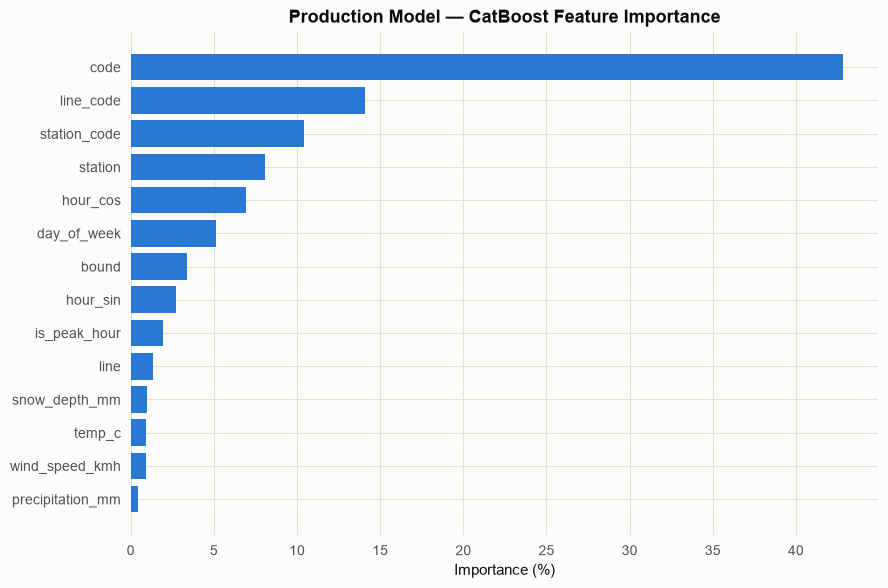

,importance
code,42.82
line_code,14.06
station_code,10.43
station,8.07
hour_cos,6.92
day_of_week,5.15
bound,3.39
hour_sin,2.74
is_peak_hour,1.92
line,1.33


In [13]:
importance = pd.Series(
    model.get_feature_importance(), index=FEATURE_COLUMNS, name="importance"
).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance.index, importance.values, color=CATEGORICAL_PALETTE[0])
ax.set_title("Production Model \u2014 CatBoost Feature Importance")
ax.set_xlabel("Importance (%)")
plt.tight_layout()
plt.show()
display(importance.sort_values(ascending=False).round(2).to_frame())

## 7. From Data to Architecture

How the findings above map onto specific decisions in the
deployed service (`app/`, `services/`):

- **`services/weather.py` fetches exactly 4 live fields
  (`temp_c`/`precipitation_mm`/`snow_depth_mm`/`wind_speed_kmh`) from a
  forecast API, and nothing more elaborate** — directly justified by
  `01_data_eda.ipynb` Section 3.4's near-zero correlations and this
  notebook's Section 6 low weather importance. There's no EDA evidence a
  richer weather feature set would earn back the engineering cost.
- **The service needs no live database access to make a prediction** —
  a direct consequence of dropping `line_avg_delay_last_24h` (Section 2).
  Every other feature is derivable from the request itself plus a
  weather lookup.
- **`services/known_categories.py` sources its validation lists from the
  same database view both notebooks' data comes from**, so the set of
  `line`/`station`/`code` values the API accepts can never drift from
  what the model was actually trained on.
- **The production model is the simple single-regressor baseline, not
  the two-stage architecture**, specifically because Section 5.2's oracle
  bound and actual routing results diverge — the idea is sound, the
  available features aren't (yet) good enough to execute it.

## 8. Summary

### The feature that got cut

`line_avg_delay_last_24h` was removed for two independent, converging reasons: low measured importance in the version of the model that had it, and — more decisively — it's incompatible with a forecast-oriented API that predicts up to 16 days out, where "today's real congestion" has no relationship to a future day. Dropping it is also *why* the deployed service needs no live database access to make a prediction.

### Production model

MAE **3.04m**, RMSE **5.82m**, R² **0.121** on the ≤60m test set (23,520 / 23,686 incidents). The error is bin-dependent, not uniform: well-calibrated under 15 minutes (MAE 1.37–3.07), then under-predicting by roughly its own magnitude in the 30–60m bin (mean residual **+31.78**, on a bin whose true mean is around 40m). `code` (42.4%) and its two interaction terms `line_code`/`station_code` (14.6% + 10.5%) account for two-thirds of feature importance combined — *what* happened and *where* dominates *when* or *what the weather was*.

### Two experiments, reproduced in this notebook, neither adopted

- **Tweedie loss** (§5.1): MAE 3.21 (worse than baseline), RMSE 5.65 (better), R² 0.171 (better) — a real but partial improvement, and even the 30–60m bin barely moved (mean residual 31.78 → 29.89). Confirms the diagnosis — a pooled loss dominated by the dense short-delay mass — without solving it.
- **Two-stage classify-then-regress** (§5.2): the *oracle* ceiling (perfect classification) reaches R² **0.680** and MAE **2.18** — proof the specialization idea is sound. The *actual* classifier only manages 20.7% precision / 71.9% recall on the "long" class, and routing on it makes every practical strategy **worse than baseline** (Hard-Routed R² **-1.27**). The bottleneck isn't the regression architecture — it's that `line`/`station`/`code`/time/weather don't contain enough signal to reliably tell in advance which specific incident is about to run long. That's why production ships the simple single-model baseline: it's not that the more ambitious idea was wrong, it's that this exact experiment shows it doesn't pay off with the features available today.

### What would actually move the needle next

Given the two experiments above, the highest-leverage next step isn't another loss function or architecture — it's new *features* that could plausibly separate long from short incidents ahead of time (real-time crowd/response signals, something closer to live severity data), since every purely structural fix tried here ran into the same ceiling: not enough signal, not the wrong model.